# Scan-to-BIM — Room Segmentation (Watershed × SAM)

A **two-pass, geometry-first / SAM-for-recall** room segmenter that fuses two ideas:

1. **Deterministic distance-transform watershed** (high *precision*). Rooms are grown
   from interior seeds (h-maxima of the free-space distance transform) and divided at
   doorway pinch-points. Unlike connected-components, a single leaked wall no longer
   merges two rooms or dumps a whole wing into "exterior" — each room has its own seed,
   so the basin boundary just falls at the leak instead of erasing the room.

2. **SAM automatic mask generation on the residual** (high *recall*, the paper's method).
   SAM's learned "enclosed region" prior recovers the rooms geometry misses — corridors,
   heavily-occluded or partially-scanned spaces — and we only run it on the free space the
   watershed left unclaimed, then **snap SAM's fuzzy masks back to walls** so boundaries
   stay crisp for 3-D back-projection.

**Why both.** Geometry is exact but brittle; SAM is robust but fuzzy. Composed, geometry
gives clean boundaries and SAM fills the gaps. Doorways are handled by *geometry* (a pinch
in the distance transform), not by a blanket seal width — and where you have a door detector,
`seal_at_doors` lets you place barriers only at real doors.

**Label convention (unchanged from your pipeline):** `-1` wall · `0` exterior · `>=1` rooms.

**Organization:** Setup → Config (`CFG`, single source of truth) → Definitions (pure stage
functions) → Run (thin drivers). SAM is optional: the watershed pass runs fully on CPU with
no model. Flip `CFG.use_sam_recall = True` once a SAM build is wired in.

## 0 · Environment setup

In [161]:
# core geometry + CV deps (always needed; CPU is fine for the watershed pass)
!pip install -q open3d supervision scikit-image scipy opencv-python-headless

# OPTIONAL — only if you will set CFG.use_sam_recall = True.
# Uncomment, and adapt build_sam_mask_generator() to your SAM build.
# USE_SAM = True
# !pip install -q torch torchvision
# !git clone https://github.com/facebookresearch/sam3.git && cd sam3 && pip install -e ".[notebooks]"

In [162]:
import math
from dataclasses import dataclass

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import open3d as o3d
import supervision as sv

from scipy import ndimage
from scipy.spatial import cKDTree
from skimage.morphology import skeletonize, h_maxima
from skimage.segmentation import watershed

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Configuration — single source of truth

Every tunable lives here; nothing downstream hard-codes a number. All thresholds are in
**metres** (the cloud is converted to metres once on load). A few notes on the new knobs:

* **`marker_h_m`** — the watershed marker control that *replaces* the brittle `max_seal_m`.
  A room core must sit at least this far (in metres of clearance) "deeper" than the saddle
  to the next space to earn its own seed. It acts on the smooth distance field, so it
  generalises across buildings far better than a pixel gap on the wall raster.
* **`merge_ridge_m`** — two adjacent basins are merged if their *widest* free connection
  exceeds this. A real doorway is narrower; a spurious split (one lumpy room) runs through
  open floor, so this cleanly undoes over-segmentation without a global area hack.
* **`footprint_close_m`** — defines an **explicit exterior** (free space outside the closed
  building footprint) instead of "anything touching the image border", so an interior room
  that leaks toward the edge is *not* mislabelled outdoors.
* **`slab_relative_to`** — `'floor'` is usually more robust than `'ceiling'`: floors are
  flatter and far less cluttered than ceilings (no beams/ducts/soffits intruding into the band).
* **`use_local_ceiling`** now uses a **smoothed** per-cell estimate (median-filtered grid),
  not the old per-point version that injected height steps at every cell boundary and broke
  wall continuity.

In [163]:
@dataclass
class Config:
    # ---- input ----
    file_path: str = '/content/drive/MyDrive/ONESTRUCTION/Uni_PointCloud_cs1_FullRes.ply'
    units_per_meter: float = 1.0
    up_axis: int = 2                       # 0=X 1=Y 2=Z

    # ---- cleaning / sampling ----
    voxel_m: float = 0.02

    # ---- slab (horizontal crop) ----
    slab_relative_to: str = 'ceiling'      # 'ceiling' | 'floor' | 'absolute'
    slab_lo_m: float = 0.2                 # shallower band edge (closer to the reference)
    slab_hi_m: float = 0.4                 # deeper band edge
    #   ceiling-relative band = [ceil - slab_hi_m, ceil - slab_lo_m]
    #   floor-relative   band = [floor + slab_lo_m, floor + slab_hi_m]
    ceiling_mode: str = 'local_perpoint'   # 'global' | 'local_smoothed' | 'local_perpoint'
    ceiling_cell_size_m: float = 0.1       # local-ceiling grid cell (smaller = finer lips)
    ceiling_min_pts_per_cell: int = 5     # sparse cells fall back to the global ceiling
    ceiling_smooth_cells: int = 3          # median window, 'local_smoothed' only

    # ---- rasterisation ----
    pixel_m: float = 0.05                  # 5 cm/px — the memory dial
    min_points_per_cell: int = 3
    thicken_px: int = 1
    use_wallness: bool = False             # vertical-extent raster vs binary presence
    wallness_min_span_frac: float = 0.5    # column counts as wall if it spans >= this
                                           #   fraction of the floor->ceiling height

    # ---- room seg: PASS 1 (deterministic watershed) ----
    min_wall_area_px: int = 60
    marker_h_m: float = 0.30               # h-maxima seed depth (replaces max_seal_m)
    footprint_close_m: float = 1.00        # explicit-exterior closing distance
    merge_ridge_m: float = 0.70            # merge basins joined wider than this
    min_room_area_m2: float = 1.0          # the paper's A threshold

    # ---- void rejection (a room must sit over scanned data) ----
    drop_empty_rooms: bool = True             # drop 'rooms' over unscanned empty space
    coverage_ceiling_margin_m: float = 0.30   # ignore points within this of the ceiling
    coverage_min_pts: int = 1                 # a cell is 'covered' with >= this many pts
    coverage_close_px: int = 2                # bridge furniture-shadow holes in coverage
    min_coverage_frac: float = 0.25           # drop a room if < this fraction is covered

    # ---- room seg: PASS 2 (SAM recall, the paper) ----
    use_sam_recall: bool = True
    sam_points: int = 11                   # paper Table 1: points_ (per case study)
    sam_iou: float = 0.85                  # pred_iou_thresh
    sam_stability: float = 0.95            # stability_score_thresh
    sam_n_layers: int = 1                  # crop_n_layers
    sam_down_factor: int = 2               # crop_n_points_downscale_factor
    sam_min_mask: int = 100                # min_mask_region_area (px)
    sam_min_overlap: float = 0.5           # keep a SAM mask if >= this fraction lies
                                           #   in the residual free space
    # SAM checkpoint/arch — adapt to your install
    sam_arch: str = 'vit_h'
    sam_ckpt: str = '/content/sam_vit_h.pth'
    sam_model_cfg: str = ''                # (SAM2/SAM3 only)

    # ---- 3-D wall export ----
    do_buffer_m: float = 0.05              # boundary buffer (~half wall thickness)
    wall_floor_margin_m: float = 0.10      # drop points within this of the floor
    wall_ceiling_margin_m: float = 0.10    # drop points within this of the ceiling

    # ---- per-room wall fit (RANSAC) ----
    ransac_dist_thresh_m: float = 0.02
    ransac_normal_tol_deg: float = 10.0
    ransac_min_inliers: int = 400
    ransac_max_planes: int = 20

    out_dir: str = '/content/scan2bim_out'

    @property
    def seal_gap_px(self) -> int:
        return 0  # blanket sealing is OFF by design; use seal_at_doors() instead

    @property
    def min_room_area_px(self) -> int:
        return int(round(self.min_room_area_m2 / (self.pixel_m ** 2)))

    @property
    def do_buffer_px(self) -> int:
        return max(1, int(round(self.do_buffer_m / self.pixel_m)))


CFG = Config()
print(f"min_room_area_px = {CFG.min_room_area_px} px^2  ({CFG.min_room_area_m2} m^2)")
print(f"marker_h_px      = {max(1, round(CFG.marker_h_m / CFG.pixel_m))} px  ({CFG.marker_h_m} m)")
print(f"merge_ridge_px   = {round(CFG.merge_ridge_m / CFG.pixel_m)} px  ({CFG.merge_ridge_m} m)")

min_room_area_px = 400 px^2  (1.0 m^2)
marker_h_px      = 6 px  (0.3 m)
merge_ridge_px   = 14 px  (0.7 m)


## 2 · IO — load / scale / downsample

In [164]:
def load_point_cloud(cfg):
    """Read the cloud, convert to METRES once, voxel-downsample."""
    pcd = o3d.io.read_point_cloud(cfg.file_path)
    raw = np.asarray(pcd.points)
    print(f"units/meter = {cfg.units_per_meter}  (raw max extent {np.ptp(raw, axis=0).max():.2f})")
    pcd.scale(1.0 / cfg.units_per_meter, center=(0, 0, 0))
    print(f"points before clean: {len(pcd.points):,}")
    pcd = pcd.voxel_down_sample(cfg.voxel_m)
    print(f"points after voxel ({cfg.voxel_m} m): {len(pcd.points):,}")
    return pcd, np.asarray(pcd.points)

## 3 · Slab extraction

`crop_vertical` keeps a horizontal slab. In `'ceiling'` mode the band is measured *down from the ceiling*, which sits in the wall-dominated zone just under the roof. `ceiling_mode` picks how the ceiling is estimated:

- `'global'` — one ceiling height for the whole building. Simple, but a dropped-ceiling **lip** (a soffit that lowers the ceiling locally) gets sliced at the wrong height: the slab catches the soffit underside, and the lip's walls collapse into one thick wall.
- `'local_perpoint'` — each cell uses its own ceiling, so the slab drops under the lip and the lip's walls stay separate. Best for multi-height ceilings; more sensitive to per-cell noise (raise `ceiling_min_pts_per_cell` or `ceiling_cell_size_m` if it looks speckly).
- `'local_smoothed'` — median-filtered local ceiling; steadier, but erases lips narrower than `ceiling_smooth_cells`.

Use the ceiling map and side elevations in 11.2 to confirm the lips are found and the band tracks them. `'floor'` mode (band measured up from the floor) stays available for flat single-height buildings.

In [165]:
def estimate_ceiling(h, bins=256, rel_thresh=0.02, return_floor=False):
    """Histogram-mass floor/ceiling: highest (lowest) bin still holding >= rel_thresh
    of the busiest bin's count, so sparse stray points are ignored."""
    h = np.asarray(h, np.float64)
    counts, edges = np.histogram(h, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    keep = np.flatnonzero(counts >= counts.max() * rel_thresh)
    floor_z, ceiling_z = centers[keep[0]], centers[keep[-1]]
    return (floor_z, ceiling_z) if return_floor else ceiling_z


def estimate_local_ceilings(points, up_axis=2, cell_size_m=1.0,
                            min_pts_per_cell=20, smooth_cells=1):
    """Per-point ceiling height from a grid of per-cell histogram-mass estimates.

    smooth_cells == 1  -> RAW per-cell: each point uses ITS OWN cell's ceiling. A
        dropped-ceiling 'lip' (a soffit/bulkhead that lowers the ceiling locally) keeps
        its true lower height, so the slab tracks under it and the lip's walls stay
        separate instead of collapsing into one thick wall. Most faithful to multi-height
        ceilings; more sensitive to per-cell noise.
    smooth_cells > 1   -> median-filter the grid first: suppresses per-cell noise but
        erases lips narrower than the window. Use only if the raw map looks speckly.
    Cells with < min_pts_per_cell points fall back to the global ceiling. Smaller
    cell_size_m resolves finer lips (at the cost of noise).
    """
    pts = np.asarray(points, np.float64); h = pts[:, up_axis]
    ax_a, ax_b = [a for a in (0, 1, 2) if a != up_axis]
    a, b = pts[:, ax_a], pts[:, ax_b]
    g = estimate_ceiling(h)
    ai = np.floor((a - a.min()) / cell_size_m).astype(int)
    bi = np.floor((b - b.min()) / cell_size_m).astype(int)
    na, nb = int(ai.max()) + 1, int(bi.max()) + 1
    grid = np.full((na, nb), g, np.float64)
    flat = ai * nb + bi
    order = np.argsort(flat, kind='stable')
    fs, hs = flat[order], h[order]
    bnd = np.flatnonzero(np.diff(fs)) + 1
    for s, e in zip(np.concatenate([[0], bnd]), np.concatenate([bnd, [len(fs)]])):
        if e - s >= min_pts_per_cell:
            x, y = divmod(int(fs[s]), nb)
            grid[x, y] = estimate_ceiling(hs[s:e])
    if smooth_cells and smooth_cells > 1:
        grid = ndimage.median_filter(grid, size=int(smooth_cells))
    return grid[ai, bi]


def crop_vertical(points, cfg, debug=False, return_info=False):
    """Keep points in a horizontal slab. Returns (slab_points, mask[, info]).

    'ceiling' mode supports cfg.ceiling_mode: 'global' | 'local_smoothed' |
    'local_perpoint'. The local modes position the band relative to the LOCAL ceiling,
    so dropped-ceiling lips are cut at the right height (see estimate_local_ceilings).
    info carries ref/keep_lo/keep_hi (scalar or per-point) for the debug views.
    """
    pts = np.asarray(points, np.float64); h = pts[:, cfg.up_axis]
    mode = cfg.slab_relative_to
    if mode == 'absolute':
        keep_lo, keep_hi, ref = cfg.slab_lo_m, cfg.slab_hi_m, None
    elif mode == 'floor':
        floor_z, _ = estimate_ceiling(h, return_floor=True)
        keep_lo, keep_hi, ref = floor_z + cfg.slab_lo_m, floor_z + cfg.slab_hi_m, floor_z
    else:  # ceiling
        cm = getattr(cfg, 'ceiling_mode', 'global')
        if cm == 'global':
            ref = estimate_ceiling(h)
        else:
            sc = 1 if cm == 'local_perpoint' else int(getattr(cfg, 'ceiling_smooth_cells', 3))
            ref = estimate_local_ceilings(pts, cfg.up_axis, cfg.ceiling_cell_size_m,
                                          cfg.ceiling_min_pts_per_cell, smooth_cells=sc)
        keep_hi = ref - cfg.slab_lo_m       # shallower cut (closer to ceiling)
        keep_lo = ref - cfg.slab_hi_m       # deeper cut
    mask = (h >= keep_lo) & (h <= keep_hi)
    if debug:
        klo = keep_lo if np.isscalar(keep_lo) else float(np.mean(keep_lo))
        khi = keep_hi if np.isscalar(keep_hi) else float(np.mean(keep_hi))
        extra = ''
        if mode == 'ceiling' and not np.isscalar(ref):
            extra = f"  local ceiling range [{float(np.min(ref)):.2f},{float(np.max(ref)):.2f}] m"
        print(f"[crop_vertical] mode={mode}  band(m,mean)=[{klo:.2f},{khi:.2f}]  "
              f"kept {int(mask.sum()):,}/{len(pts):,} ({100*mask.mean():.1f}%){extra}")
    info = dict(mode=mode, ref=ref, keep_lo=keep_lo, keep_hi=keep_hi)
    return (pts[mask], mask, info) if return_info else (pts[mask], mask)

## 4 · Rasterise to a top-down occupancy image

`rasterize_topdown` is the binary presence raster you already use. `rasterize_wallness` is the
optional upgrade I recommended: each pixel carries the **vertical extent** of points in that
column, computed from the *full* cloud — tall columns (floor→ceiling) are walls, short ones are
furniture, doorway columns are empty at slab height. Thresholding that span gives a far cleaner
wall mask that suppresses furniture at the source. Off by default so behaviour matches your
current binary path.

In [166]:
def rasterize_topdown(sliced_points, pixel_size, up_axis=2,
                      min_points_per_cell=1, thicken=0, max_cells=150_000_000,
                      save_path=None):
    """Binary occupancy (0=wall, 255=free) + transform dict."""
    pts = np.asarray(sliced_points, np.float64)
    assert pts.ndim == 2 and pts.shape[1] == 3 and len(pts) > 0
    ax_a, ax_b = [a for a in (0, 1, 2) if a != up_axis]
    a, b = pts[:, ax_a], pts[:, ax_b]
    a_px = ((a - a.min()) / pixel_size).astype(np.int64)
    b_px = ((b - b.min()) / pixel_size).astype(np.int64)
    width, height = int(a_px.max()) + 1, int(b_px.max()) + 1
    if width * height > max_cells:
        raise MemoryError(f"Grid {width*height:,} cells — raise pixel_size (unit mismatch?).")
    counts = np.zeros((height, width), np.uint16)
    np.add.at(counts, (b_px, a_px), 1)
    wall = (counts >= min_points_per_cell)[::-1, :]            # flip: world-up = image-up
    for _ in range(int(thicken)):
        w = wall.copy()
        w[1:, :] |= wall[:-1, :]; w[:-1, :] |= wall[1:, :]
        w[:, 1:] |= wall[:, :-1]; w[:, :-1] |= wall[:, 1:]
        wall = w
    occ = np.where(wall, 0, 255).astype(np.uint8)
    tf = dict(a_min=a.min(), b_min=b.min(), pixel_size=pixel_size,
              width=width, height=height, ax_a=ax_a, ax_b=ax_b, up_axis=up_axis)
    if save_path:
        Image.fromarray(occ).save(save_path)
    return occ, tf


def rasterize_wallness(full_points, cfg, transform):
    """Vertical-EXTENT raster from the FULL cloud, aligned to `transform`'s grid.
    Returns a bool wall mask: column is wall if its point span covers >=
    wallness_min_span_frac of the floor->ceiling height."""
    pts = np.asarray(full_points, np.float64)
    up = cfg.up_axis
    floor_z, ceil_z = estimate_ceiling(pts[:, up], return_floor=True)
    room_h = max(1e-6, ceil_z - floor_z)
    ax_a, ax_b, ps = transform['ax_a'], transform['ax_b'], transform['pixel_size']
    H, W = transform['height'], transform['width']
    a_px = ((pts[:, ax_a] - transform['a_min']) / ps).astype(np.int64)
    b_px = ((pts[:, ax_b] - transform['b_min']) / ps).astype(np.int64)
    inb = (a_px >= 0) & (a_px < W) & (b_px >= 0) & (b_px < H)
    a_px, b_px, z = a_px[inb], b_px[inb], pts[inb, up]
    flat = b_px * W + a_px
    zmax = np.full(H * W, -np.inf); zmin = np.full(H * W, np.inf)
    np.maximum.at(zmax, flat, z); np.minimum.at(zmin, flat, z)
    span = (zmax - zmin).reshape(H, W)
    span[~np.isfinite(span)] = 0.0
    wall = span >= cfg.wallness_min_span_frac * room_h
    return wall[::-1, :]                                       # match the row flip


def rasterize_coverage(full_points, cfg, transform):
    """Bool map of where the scan actually HAS DATA below the ceiling (floor +
    furniture + low structure), aligned to transform's grid. A cell is 'covered' if it
    holds >= coverage_min_pts such points. The ceiling slab is excluded, so a void that
    merely has a ceiling scanned over it still reads as empty. Used to drop 'rooms' that
    are really unscanned voids -- they would otherwise steal walls and export bogus data.
    """
    pts = np.asarray(full_points, np.float64); up = cfg.up_axis
    floor_z, ceil_z = estimate_ceiling(pts[:, up], return_floor=True)
    lo = floor_z - 0.2
    hi = ceil_z - cfg.coverage_ceiling_margin_m       # exclude the ceiling slab + above
    sel = (pts[:, up] >= lo) & (pts[:, up] <= hi)
    p = pts[sel]
    ax_a, ax_b, ps = transform['ax_a'], transform['ax_b'], transform['pixel_size']
    H, W = transform['height'], transform['width']
    a_px = ((p[:, ax_a] - transform['a_min']) / ps).astype(np.int64)
    b_px = ((p[:, ax_b] - transform['b_min']) / ps).astype(np.int64)
    inb = (a_px >= 0) & (a_px < W) & (b_px >= 0) & (b_px < H)
    cov = np.zeros((H, W), np.int32)
    np.add.at(cov, (b_px[inb], a_px[inb]), 1)
    covered = (cov >= int(cfg.coverage_min_pts))
    c = int(cfg.coverage_close_px)
    if c > 0:                                          # bridge furniture-shadow holes
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * c + 1, 2 * c + 1))
        covered = cv2.morphologyEx(covered.astype(np.uint8), cv2.MORPH_CLOSE, ker).astype(bool)
    return covered[::-1, :]                            # match the row flip

## 5 · Wall cleanup + door-located sealing

`clean_wall_mask` drops speckle. **Blanket gap-bridging is off by design** — the watershed
splits at doorways geometrically, so you no longer need a one-size gap width. `seal_at_doors`
is the principled replacement: feed it door pixel locations from your door-detection module
(or scanner trajectory) and it places barriers *only* at real doors. Without doors it does
nothing, and the watershed still works.

In [167]:
def _fill_holes(mask_bool):
    m = mask_bool.astype(np.uint8); h, w = m.shape
    ff = m.copy(); flood = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(ff, flood, (0, 0), 1)
    return mask_bool | (ff == 0)


def _building_footprint(walls, close_px):
    """Filled OUTER CONTOUR of the walls = building footprint. Leak-immune: a gap in
    an outer wall does not re-open the interior the way fill-holes-after-close does,
    because the outer contour still wraps the building."""
    w = walls.astype(np.uint8)
    ker = None
    if close_px > 0:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * close_px + 1, 2 * close_px + 1))
        w = cv2.dilate(w, ker)                 # heal leaks/hairline gaps first
    cnts, _ = cv2.findContours(w, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    f = np.zeros_like(w)
    cv2.drawContours(f, cnts, -1, 1, thickness=cv2.FILLED)
    if ker is not None:
        f = cv2.erode(f, ker)                  # undo the dilation -> hug the walls
    return f.astype(bool)


def _interior_seed(mask_bool):
    """Distance-transform peak -> safe interior point (valid for L-shapes). (x, y)."""
    dist = cv2.distanceTransform(mask_bool.astype(np.uint8), cv2.DIST_L2, 5)
    y, x = np.unravel_index(int(np.argmax(dist)), dist.shape)
    return int(x), int(y)


def clean_wall_mask(wall_mask, min_wall_area=60, seal_gap=0):
    """Drop tiny black components (noise). seal_gap kept for API compatibility but
    defaults to 0 — prefer seal_at_doors()."""
    wm = (np.asarray(wall_mask) > 0).astype(np.uint8)
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(wm, connectivity=8)
    keep = np.zeros_like(wm)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_wall_area:
            keep[lbl == i] = 1
    walls = keep.astype(bool)
    if seal_gap > 0:
        walls = bridge_wall_endpoints(walls, max_gap=seal_gap)
    return walls


def seal_at_doors(wall_mask, doors_px, thickness=None):
    """Place wall barriers ONLY at detected doors. doors_px: list of (x0,y0,x1,y1) line
    segments (image px) spanning each door opening. This is the principled replacement for
    a blanket seal width."""
    wm = (np.asarray(wall_mask) > 0).astype(np.uint8)
    if thickness is None:
        dist = cv2.distanceTransform(wm, cv2.DIST_L2, 5)
        pos = dist[dist > 0]
        thickness = max(1, int(round(2 * np.median(pos)))) if pos.size else 2
    out = wm.copy()
    for (x0, y0, x1, y1) in doors_px:
        cv2.line(out, (int(x0), int(y0)), (int(x1), int(y1)), 1, int(thickness))
    return out.astype(bool)


# legacy collinear-endpoint bridger (kept; used only if you pass seal_gap > 0)
def _endpoints_and_tangents(skel):
    sk = skel.astype(np.uint8)
    k = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])
    neigh = ndimage.convolve(sk, k, mode="constant")
    eps = np.argwhere((sk == 1) & (neigh == 1))
    ys, xs = np.where(sk); pts = np.column_stack([ys, xs])
    tree = cKDTree(pts); tangents = []
    for (y, x) in eps:
        loc = pts[tree.query_ball_point([y, x], r=6)]
        v = np.array([y, x]) - loc.mean(0); n = np.linalg.norm(v)
        tangents.append(v / n if n else np.zeros(2))
    return eps, (np.array(tangents) if tangents else np.zeros((0, 2)))


def bridge_wall_endpoints(wall_mask, max_gap=12, max_angle_deg=45, thickness=None):
    wm = (np.asarray(wall_mask) > 0).astype(np.uint8)
    if thickness is None:
        dist = cv2.distanceTransform(wm, cv2.DIST_L2, 5)
        thickness = max(1, int(round(2 * np.median(dist[dist > 0]))))
    eps, tang = _endpoints_and_tangents(skeletonize(wm > 0))
    if len(eps) < 2:
        return wm.astype(bool)
    tree = cKDTree(eps); out = wm.copy()
    cos_thr = np.cos(np.deg2rad(max_angle_deg)); used = set()
    cand = sorted((np.linalg.norm(eps[i] - eps[j]), i, j)
                  for i, j in tree.query_pairs(r=max_gap))
    for d, i, j in cand:
        if i in used or j in used:
            continue
        pi, pj = eps[i].astype(float), eps[j].astype(float)
        seg = (pj - pi) / (np.linalg.norm(pj - pi) + 1e-9)
        if np.dot(tang[i], seg) < cos_thr or np.dot(tang[j], -seg) < cos_thr:
            continue
        cv2.line(out, (int(pi[1]), int(pi[0])), (int(pj[1]), int(pj[0])), 1, thickness)
        used.add(i); used.add(j)
    return out.astype(bool)

## 6 · Pass 1 — deterministic distance-transform watershed

The high-precision segmenter. Rooms are basins of the free-space distance transform, seeded by
h-maxima and flooded with walls as barriers, so they **split at doorway pinch-points
automatically**. An explicit exterior (free space outside the closed footprint) means a leaked
room is not mislabelled outdoors, and `merge_wide_connections` folds back any room a lumpy
interior over-split. Verified on synthetic plans: rooms split at doorways, survive a leaked
outer wall, and a single open-partition room stays one room.

**Empty-space rejection.** Free space in the wall raster only means "no wall at slab height" — it can't tell an open room from an unscanned hole, so the watershed will turn a void into a room and let it steal the surrounding walls. After segmentation we therefore check each room against a *scan-coverage* map (where the cloud actually has floor/data below the ceiling) and drop any room that sits over too little real data (`min_coverage_frac`).

In [168]:
def _min_inscribed_radius_m(mask_bool, pixel_m):
    """Largest circle that fits inside the region, in metres (= max internal DT).
    Long thin ribbons score tiny; real rooms score large."""
    dt_in = cv2.distanceTransform(mask_bool.astype(np.uint8), cv2.DIST_L2, 5)
    return float(dt_in.max()) * pixel_m

def _is_phantom(frac, radius_m, cov_strong=0.90, radius_strong_m=0.60,
                radius_hard_m=0.30):
    """Drop a region only if it fails to look like a real room.
    A real room is EITHER comfortably wide OR solidly scanned.
    A phantom is narrow AND poorly covered (reflection sliver, wall spine)."""
    if radius_m < radius_hard_m:
        return True                       # too thin to fit a person, period
    if radius_m < radius_strong_m and frac < cov_strong:
        return True                       # narrow AND not solidly scanned
    return False

def _relabel_rooms(labels):
    """Compact room ids to 1..k after some were dropped (walls/exterior untouched)."""
    out = labels.copy()
    for new, r in enumerate([int(x) for x in np.unique(labels) if x >= 1], start=1):
        out[labels == r] = new
    return out


def merge_wide_connections(labels, dt, merge_ridge_m, pixel_m, wall_mask=None,
                           open_border_frac=0.80, min_border_px=8):
    """Merge adjacent room basins when EITHER:
      (a) their widest shared free connection exceeds merge_ridge_m (doorway-width), OR
      (b) their shared border is mostly open floor, not wall (corridor saddle split).
    (b) catches long thin spaces that (a) misses because a corridor's DT-at-boundary
    reflects side-wall distance, not how connected the two segments are."""
    ridge_px = merge_ridge_m / pixel_m
    ids = [int(r) for r in np.unique(labels) if r >= 1]
    if len(ids) < 2:
        return labels
    parent = {r: r for r in ids}
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    contact = {}          # max free width at the join (existing metric)
    border_tot = {}       # total boundary pixels between a pair
    border_wall = {}      # how many of those sit on a wall

    def add_pairs(la, lb, da, db, wa, wb):
        m = (la >= 1) & (lb >= 1) & (la != lb)
        if not m.any(): return
        xs, ys = la[m], lb[m]
        ds = np.maximum(da[m], db[m])
        # a border pixel is "wall" if a wall pixel sits on either side of the seam
        ws = (wa[m] | wb[m]) if wa is not None else np.zeros(m.sum(), dtype=bool)
        for x, y, d, w in zip(xs, ys, ds, ws):
            key = (min(int(x), int(y)), max(int(x), int(y)))
            if d > contact.get(key, 0.0): contact[key] = float(d)
            border_tot[key] = border_tot.get(key, 0) + 1
            border_wall[key] = border_wall.get(key, 0) + (1 if w else 0)

    W = wall_mask
    if W is not None:
        add_pairs(labels[:, :-1], labels[:, 1:], dt[:, :-1], dt[:, 1:], W[:, :-1], W[:, 1:])
        add_pairs(labels[:-1, :], labels[1:, :], dt[:-1, :], dt[1:, :], W[:-1, :], W[1:, :])
    else:
        add_pairs(labels[:, :-1], labels[:, 1:], dt[:, :-1], dt[:, 1:], None, None)
        add_pairs(labels[:-1, :], labels[1:, :], dt[:-1, :], dt[1:, :], None, None)

    for (a, b), d in contact.items():
        tot = border_tot.get((a, b), 0)
        wall = border_wall.get((a, b), 0)
        open_frac = 1.0 - (wall / tot) if tot else 0.0
        wide_doorway = d >= ridge_px
        open_corridor = (tot >= min_border_px) and (open_frac >= open_border_frac)
        if wide_doorway or open_corridor:
            union(a, b)

    out = labels.copy(); newid = {}; nxt = 1
    for r in ids:
        root = find(r)
        if root not in newid: newid[root] = nxt; nxt += 1
    for r in ids:
        out[labels == r] = newid[find(r)]
    return out

def bridge_pinched_corridor(labels, dt, pixel_m,
                            max_obstruction_m=1.2, min_elongation=2.5,
                            min_open_flank_m=0.3):
    """Merge two basins separated only by a SHORT obstruction (e.g. a pipe-blob or
    column) when both basins are corridor-shaped. Unlike merge_wide_connections this
    bridges across a thin WALL barrier -- but only if it's short (not a full wall) and
    the regions are elongated (corridors, not rooms). Operates on labels only; never
    touches the wall mask.

      max_obstruction_m : the gap between basins must be <= this to be a 'pinch'
      min_elongation    : a basin merges only if it's at least this elongated
                          (major/minor axis) -> protects blobby rooms
      min_open_flank_m  : there must be open floor at least this wide beside the
                          obstruction -> distinguishes a pinch from a full-width wall
    """
    from scipy import ndimage as ndi
    ids = [int(r) for r in np.unique(labels) if r >= 1]
    if len(ids) < 2:
        return labels

    def elongation(mask):
        ys, xs = np.where(mask)
        if len(xs) < 5: return 0.0
        cov = np.cov(np.vstack([xs, ys]))
        ev = np.linalg.eigvalsh(cov)
        ev = np.clip(ev, 1e-6, None)
        return float(np.sqrt(ev[-1] / ev[0]))

    elong = {r: elongation(labels == r) for r in ids}
    max_gap_px = max_obstruction_m / pixel_m

    parent = {r: r for r in ids}
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    bridged = []
    for i, a in enumerate(ids):
        if elong[a] < min_elongation:            # 'a' must be corridor-like
            continue
        mask_a = (labels == a)
        # how far does each non-a pixel sit from basin a?
        dist_to_a = ndi.distance_transform_edt(~mask_a)
        for b in ids[i+1:]:
            if elong[b] < min_elongation:        # 'b' must be corridor-like too
                continue
            mask_b = (labels == b)
            gap_px = dist_to_a[mask_b].min()     # nearest approach a<->b
            if gap_px == 0 or gap_px > max_gap_px:
                continue                         # touching already, or too far apart
            # is there OPEN FLOOR beside the obstruction? check the free-space (dt>0)
            # midline band between the two basins' nearest points
            # approximate: dilate both by the gap, intersect -> the bridging corridor
            grow = int(np.ceil(gap_px)) + 1
            ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*grow+1, 2*grow+1))
            band = (cv2.dilate(mask_a.astype(np.uint8), ker).astype(bool)
                    & cv2.dilate(mask_b.astype(np.uint8), ker).astype(bool))
            free_in_band = (dt > 0) & band       # open floor in the bridging zone
            flank_m = free_in_band.sum() * (pixel_m ** 2) / max(pixel_m, gap_px*pixel_m)
            if flank_m >= min_open_flank_m:
                union(a, b)
                bridged.append((a, b, round(gap_px*pixel_m, 2)))

    if bridged:
        print(f"[bridge-corridor] merged pinched pairs: {bridged}")
    out = labels.copy(); newid = {}; nxt = 1
    for r in ids:
        root = find(r)
        if root not in newid: newid[root] = nxt; nxt += 1
    for r in ids:
        out[labels == r] = newid[find(r)]
    return out


def segment_rooms_watershed(wall_mask, pixel_m, marker_h_m=0.30,
                            footprint_close_m=1.0, merge_ridge_m=0.70,
                            min_room_area_m2=2.0, min_wall_area_px=60,
                            door_seal_px=0, coverage=None, min_coverage_frac=0.25,
                            return_aux=False):
    """Deterministic room labels.  -1 wall · 0 exterior · >=1 rooms."""
    walls = clean_wall_mask(wall_mask, min_wall_area=min_wall_area_px, seal_gap=door_seal_px)
    free = ~walls
    dt = cv2.distanceTransform(free.astype(np.uint8), cv2.DIST_L2, 5)

    # interior seeds: maxima at least marker_h_m "deep"
    h = max(1.0, marker_h_m / pixel_m)
    markers, n_int = ndimage.label(h_maxima(dt, h))

    # explicit exterior = free space outside the building footprint (leak-immune)
    k = max(1, int(round(footprint_close_m / pixel_m)))
    footprint = _building_footprint(walls, k)
    exterior_seed = free & (~footprint)
    markers = markers.copy(); ext_id = n_int + 1
    if exterior_seed.any():
        markers[exterior_seed] = ext_id

    ws = watershed(-dt, markers, mask=free)                    # walls are barriers

    labels = np.full(wall_mask.shape, -1, np.int32); labels[free] = 0
    min_area_px = int(round(min_room_area_m2 / (pixel_m ** 2)))
    rid = 1
    for b in range(1, n_int + 1):
        m = (ws == b)
        if m.sum() == 0:
            continue
        inside = (m & footprint).sum() / m.sum()
        if m.sum() >= min_area_px and inside >= 0.5:           # big + indoors -> room
            labels[m] = rid; rid += 1
        else:
            labels[m] = 0                                      # speckle / outdoor blob
    labels[ws == ext_id] = 0
    labels = merge_wide_connections(labels, dt, merge_ridge_m, pixel_m, wall_mask=walls)
    labels = bridge_pinched_corridor(labels, dt, pixel_m)

    # void rejection: a real room sits over scanned data; an unscanned hole does not.
    pre_drop = labels.copy(); room_cov = {}
    if coverage is not None:
        for r in [int(x) for x in np.unique(labels) if x >= 1]:
            interior = (labels == r)
            frac = float((interior & coverage).sum() / max(1, int(interior.sum())))
            radius_m = _min_inscribed_radius_m(interior, pixel_m)
            room_cov[r] = frac
            if frac < min_coverage_frac or _is_phantom(frac, radius_m):
                labels[interior] = 0                  # void OR ribbon -> not a room
        labels = _relabel_rooms(labels)

    if return_aux:
        return labels, dict(walls=walls, dt=dt, footprint=footprint,
                            seeds=markers, ws=ws, exterior=exterior_seed,
                            n_int=n_int, ext_id=ext_id,
                            coverage=coverage, pre_drop=pre_drop, room_coverage=room_cov)
    return labels


def labels_to_detections(labels):
    """sv.Detections straight from the label array -> overlay == export."""
    ids = [int(r) for r in np.unique(labels) if r >= 1]
    if not ids:
        return sv.Detections.empty()
    masks, boxes = [], []
    for r in ids:
        m = (labels == r); ys, xs = np.where(m)
        boxes.append([int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())])
        masks.append(m)
    return sv.Detections(xyxy=np.array(boxes, float), mask=np.array(masks),
                         confidence=np.ones(len(ids), float))

## 7 · Pass 2 — SAM recall on the residual (the paper) + fusion

The paper's automatic mask generation, applied **only to the free space Pass 1 left unclaimed**
(label `0` inside the footprint). SAM's learned prior recovers corridors / occluded rooms that
the geometry misses. Each kept mask is **snapped to walls** (intersected with free space, largest
connected piece kept) so boundaries stay crisp, then fused as new room ids *without overwriting*
the confident geometry rooms.

> **Adapt `build_sam_mask_generator` to your SAM install.** The body targets the standard
> `SamAutomaticMaskGenerator` interface and the paper's Table 1 parameters. The whole pass is
> guarded by `CFG.use_sam_recall`, so the notebook runs end-to-end without a model.

In [169]:
def build_sam_mask_generator(cfg):
    """Construct a SAM automatic mask generator. ADAPT imports/ctor to your build."""
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    try:
        from sam2.build_sam import build_sam2
        from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator as AMG
        sam = build_sam2(cfg.sam_model_cfg, cfg.sam_ckpt, device=device)
        return AMG(sam, points_per_side=cfg.sam_points,
                   pred_iou_thresh=cfg.sam_iou, stability_score_thresh=cfg.sam_stability,
                   crop_n_layers=cfg.sam_n_layers,
                   crop_n_points_downscale_factor=cfg.sam_down_factor,
                   min_mask_region_area=cfg.sam_min_mask)
    except Exception:
        from segment_anything import sam_model_registry, SamAutomaticMaskGenerator as AMG
        sam = sam_model_registry[cfg.sam_arch](checkpoint=cfg.sam_ckpt).to(device)
        return AMG(sam, points_per_side=cfg.sam_points,
                   pred_iou_thresh=cfg.sam_iou, stability_score_thresh=cfg.sam_stability,
                   crop_n_layers=cfg.sam_n_layers,
                   crop_n_points_downscale_factor=cfg.sam_down_factor,
                   min_mask_region_area=cfg.sam_min_mask)


def sam_auto_masks(generator, occ_gray):
    rgb = np.stack([occ_gray] * 3, -1).astype(np.uint8)
    return [m['segmentation'].astype(bool) for m in generator.generate(rgb)]


def sam_rooms_on_residual(sam_masks, walls, geom_labels, footprint, pixel_m,
                          min_room_area_m2=2.0, min_overlap=0.5):
    """Keep SAM masks that lie mostly in residual free space (indoors, unclaimed by Pass 1),
    snap them to walls, return bool room masks to fuse."""
    free = ~walls
    residual = free & (geom_labels == 0) & footprint
    min_area_px = int(round(min_room_area_m2 / (pixel_m ** 2)))
    out = []
    for m in sam_masks:
        m = m & free                                           # snap off walls
        if m.sum() < min_area_px:
            continue
        if (m & residual).sum() < min_overlap * m.sum():       # mostly already claimed
            continue
        lbl, n = ndimage.label(m)                              # reject wall-straddling
        if n == 0:
            continue
        sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n + 1))
        out.append(lbl == (int(np.argmax(sizes)) + 1))         # keep largest piece
    return out


def fuse_labels(geom_labels, sam_room_masks):
    """Add SAM rooms as new ids ONLY where geometry left free space unclaimed (label 0)."""
    out = geom_labels.copy(); nxt = int(out.max()) + 1
    for m in sam_room_masks:
        m = m & (out == 0)
        if m.sum() == 0:
            continue
        out[m] = nxt; nxt += 1
    return out

## 8 · Overlay annotator

In [170]:
COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"])

def annotate(image, detections, label=None):
    ma = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.INDEX, opacity=0.6)
    out = ma.annotate(image.copy(), detections)
    return out

## 9 · Project labels to 3-D + split into per-room wall clouds

In [171]:
def point_cells(points, transform):
    pts = np.asarray(points, np.float64)
    ax_a, ax_b, ps = transform['ax_a'], transform['ax_b'], transform['pixel_size']
    H, W = transform['height'], transform['width']
    a_px = ((pts[:, ax_a] - transform['a_min']) / ps).astype(np.int64)
    b_px = ((pts[:, ax_b] - transform['b_min']) / ps).astype(np.int64)
    row = H - 1 - b_px; col = a_px
    inb = (col >= 0) & (col < W) & (b_px >= 0) & (b_px < H)
    return row, col, inb


def label_points(points, labels, transform):
    row, col, inb = point_cells(points, transform)
    out = np.full(len(row), -2, np.int32)
    out[inb] = labels[row[inb], col[inb]]
    return out


def room_footprints(labels, margin=1, thickness=None, walls_only=False):
    wall_mask = (labels == -1)
    if thickness is None:
        dist = cv2.distanceTransform(wall_mask.astype(np.uint8), cv2.DIST_L2, 5)
        pos = dist[dist > 0]
        thickness = int(round(2 * np.median(pos))) if pos.size else 1
    k = max(1, thickness + margin)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * k + 1, 2 * k + 1))
    foot = {}
    for r in np.unique(labels):
        if r < 1:
            continue
        interior = (labels == r)
        grown = cv2.dilate(interior.astype(np.uint8), kernel).astype(bool)
        band = grown & wall_mask
        foot[int(r)] = band if walls_only else (interior | band)
    return foot


def split_rooms_to_clouds(points, labels, transform, colors=None,
                          margin=1, thickness=None, walls_only=False, keep_mask=None):
    row, col, inb = point_cells(points, transform)
    foot = room_footprints(labels, margin=margin, thickness=thickness, walls_only=walls_only)
    pts = np.asarray(points); cols = np.asarray(colors) if colors is not None else None
    keep = None if keep_mask is None else np.asarray(keep_mask, bool)
    out = []
    for rid, fmask in sorted(foot.items()):
        sel = np.zeros(len(pts), bool); sel[inb] = fmask[row[inb], col[inb]]
        if keep is not None:
            sel &= keep
        e = {'room_id': rid, 'mask': sel, 'points': pts[sel]}
        if cols is not None:
            e['colors'] = cols[sel]
        out.append(e)
    return out


def fit_walls_in_room(pc, up_axis=2, normal_tol_deg=10, dist_thresh=0.02,
                      min_inliers=400, max_planes=20, dbscan_eps_mult=8):
    if len(pc.points) < min_inliers:
        return []
    pc.estimate_normals()
    up = np.zeros(3); up[up_axis] = 1.0
    sin_tol = np.sin(np.deg2rad(normal_tol_deg))
    n = np.asarray(pc.normals)
    cand = pc.select_by_index(np.where(np.abs(n @ up) < sin_tol)[0])
    walls, rest = [], cand
    while len(rest.points) >= min_inliers and len(walls) < max_planes:
        model, inl = rest.segment_plane(dist_thresh, 3, 1000)
        if len(inl) < min_inliers:
            break
        nrm = np.array(model[:3]); nrm /= np.linalg.norm(nrm) + 1e-9
        if abs(nrm @ up) < sin_tol:
            seg = rest.select_by_index(inl)
            lbl = np.array(seg.cluster_dbscan(eps=dist_thresh * dbscan_eps_mult,
                                              min_points=max(10, min_inliers // 4)))
            for c in sorted(set(lbl) - {-1}):
                walls.append({'model': model, 'cloud': seg.select_by_index(np.where(lbl == c)[0])})
        rest = rest.select_by_index(inl, invert=True)
    return walls

## 10 · Debug visualizations

A matplotlib helper per stage so you can *see* every intermediate product, not just the
final labels. The run cells below call these after each step. The richest one is
`show_watershed_internals`, which lays out the six internal stages of Pass 1 side by side:

* **Missing room?** Check panel 3 (seeds) — it had no h-maximum. Lower `marker_h_m`, or the
  space is too cluttered/open for a clean distance ridge (a job for the SAM pass).
* **Two rooms fused into one?** Panel 5 (raw basins) shows them as a single basin — either a
  real wall gap (check panel 1) or `merge_ridge_m` is too high.
* **A room swallowed by exterior?** Panel 4 — the footprint (blue) didn't enclose it; raise
  `footprint_close_m`.

In [172]:
def _subsample(n, k=150_000):
    if n <= k:
        return np.arange(n)
    return np.random.default_rng(0).choice(n, k, replace=False)


def colorize_labels(labels):
    # -1 wall -> black, 0 exterior -> light grey, rooms -> tab20
    H, W = labels.shape
    rgb = np.ones((H, W, 3))
    rgb[labels == -1] = (0, 0, 0)
    rgb[labels == 0] = (0.93, 0.93, 0.93)
    cmap = plt.get_cmap('tab20')
    for k, r in enumerate([int(x) for x in np.unique(labels) if x >= 1]):
        rgb[labels == r] = cmap(k % 20)[:3]
    return rgb


def _annotate_ids(ax, labels):
    for r in [int(x) for x in np.unique(labels) if x >= 1]:
        ys, xs = np.where(labels == r)
        ax.text(xs.mean(), ys.mean(), str(r), color='k', fontsize=9, ha='center',
                va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))


def _color_basins(ws, ext_id):
    H, W = ws.shape
    rgb = np.ones((H, W, 3))
    rng = np.random.default_rng(1)
    for v in [int(x) for x in np.unique(ws) if x > 0]:
        rgb[ws == v] = (0.85, 0.85, 0.85) if v == ext_id else (rng.random(3) * 0.7 + 0.15)
    return rgb


def show_topdown(points, up_axis, title='top-down'):
    pts = np.asarray(points)
    aa, bb = [a for a in (0, 1, 2) if a != up_axis]
    s = _subsample(len(pts), 200_000)
    plt.figure(figsize=(9, 7))
    sc = plt.scatter(pts[s, aa], pts[s, bb], s=0.5, c=pts[s, up_axis], cmap='viridis')
    plt.colorbar(sc, label='height (m)'); plt.gca().set_aspect('equal')
    plt.title(title); plt.tight_layout(); plt.show()


def show_slab_debug(points, slab_mask, up_axis, info=None):
    # 4 panels: height histogram, top-down, and TWO side elevations. With a local
    # ceiling, the side panels overlay the ceiling profile (blue) and the band edges
    # (orange) so you can SEE the slab step down under a dropped-ceiling lip.
    pts = np.asarray(points); h = pts[:, up_axis]; kept = pts[slab_mask]
    aa, bb = [a for a in (0, 1, 2) if a != up_axis]
    nm = {0: 'X', 1: 'Y', 2: 'Z'}
    lo, hi = kept[:, up_axis].min(), kept[:, up_axis].max()
    sa = _subsample(len(pts)); sk = _subsample(len(kept))

    def arr(key):
        if info is None or key not in info or info[key] is None or np.isscalar(info[key]):
            return None
        return np.asarray(info[key])
    ref, klo, khi = arr('ref'), arr('keep_lo'), arr('keep_hi')

    fig, ax = plt.subplots(2, 2, figsize=(15, 11))
    ax[0, 0].hist(h, bins=200, color='steelblue')
    ax[0, 0].axvspan(lo, hi, color='orange', alpha=0.35)
    ax[0, 0].axvline(lo, color='r', lw=1); ax[0, 0].axvline(hi, color='r', lw=1)
    ax[0, 0].set_title(f'height histogram + slab band (mean [{lo:.2f}, {hi:.2f}] m)')
    ax[0, 0].set_xlabel(f'{nm[up_axis]} (m)'); ax[0, 0].set_ylabel('point count')

    ax[0, 1].scatter(pts[sa, aa], pts[sa, bb], s=0.5, c='lightgray')
    ax[0, 1].scatter(kept[sk, aa], kept[sk, bb], s=0.5, c='crimson')
    ax[0, 1].set_aspect('equal'); ax[0, 1].set_title('top-down (slab red over all grey)')
    ax[0, 1].set_xlabel(nm[aa]); ax[0, 1].set_ylabel(nm[bb])

    for col, axis in ((0, aa), (1, bb)):
        A = ax[1, col]
        A.scatter(pts[sa, axis], pts[sa, up_axis], s=0.5, c='lightgray')
        A.scatter(kept[sk, axis], kept[sk, up_axis], s=0.6, c='crimson')
        if ref is not None:
            A.scatter(pts[sa, axis], ref[sa], s=0.4, c='#1f6fb4', alpha=0.5)
        if klo is not None and khi is not None:
            A.scatter(pts[sa, axis], khi[sa], s=0.3, c='orange', alpha=0.5)
            A.scatter(pts[sa, axis], klo[sa], s=0.3, c='orange', alpha=0.5)
        else:
            A.axhspan(lo, hi, color='orange', alpha=0.12)
            A.axhline(lo, color='r', lw=0.6); A.axhline(hi, color='r', lw=0.6)
        A.set_title(f'side: {nm[axis]} vs {nm[up_axis]}  (blue = ceiling, orange = band)')
        A.set_xlabel(nm[axis]); A.set_ylabel(f'{nm[up_axis]} (m)')
    plt.tight_layout(); plt.show()


def show_ceiling_map(points, cfg):
    # Top-down map of the LOCAL ceiling height + its distribution. Dropped-ceiling lips
    # show up as lower-coloured patches, and as a second peak in the histogram. This is
    # how you confirm the local ceiling is finding the lips before they reach the raster.
    pts = np.asarray(points, np.float64); up = cfg.up_axis
    aa, bb = [a for a in (0, 1, 2) if a != up]; nm = {0: 'X', 1: 'Y', 2: 'Z'}
    ceil_pp = estimate_local_ceilings(pts, up, cfg.ceiling_cell_size_m,
                                      cfg.ceiling_min_pts_per_cell, smooth_cells=1)
    g = estimate_ceiling(pts[:, up])
    s = _subsample(len(pts), 200_000)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sc = ax[0].scatter(pts[s, aa], pts[s, bb], s=1, c=ceil_pp[s], cmap='viridis')
    ax[0].set_aspect('equal'); fig.colorbar(sc, ax=ax[0], label='local ceiling height (m)')
    ax[0].set_title(f'local ceiling map (global = {g:.2f} m) — lower patches = dropped lips')
    ax[0].set_xlabel(nm[aa]); ax[0].set_ylabel(nm[bb])
    ax[1].hist(ceil_pp, bins=120, color='teal')
    ax[1].axvline(g, color='r', lw=1, label=f'global {g:.2f} m')
    ax[1].set_title('ceiling-height distribution (separate peaks = separate heights)')
    ax[1].set_xlabel('ceiling height (m)'); ax[1].set_ylabel('point count'); ax[1].legend()
    plt.tight_layout(); plt.show()

def show_raster_debug(wall_mask):
    free = ~wall_mask
    dt = cv2.distanceTransform(free.astype(np.uint8), cv2.DIST_L2, 5)
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ax[0].imshow(wall_mask, cmap='gray_r'); ax[0].set_title('wall mask (black = wall)')
    im = ax[1].imshow(dt, cmap='magma'); ax[1].set_title('distance transform (px to wall)')
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()


def show_watershed_internals(aux, labels, pixel_m):
    walls, dt, foot = aux['walls'], aux['dt'], aux['footprint']
    seeds, ws, ext = aux['seeds'], aux['ws'], aux['exterior']; ext_id = aux['ext_id']
    fig, ax = plt.subplots(2, 3, figsize=(16, 9))
    ax[0, 0].imshow(walls, cmap='gray_r'); ax[0, 0].set_title('1 · cleaned walls')
    im = ax[0, 1].imshow(dt, cmap='magma'); ax[0, 1].set_title('2 · distance transform')
    fig.colorbar(im, ax=ax[0, 1], fraction=0.046)
    ax[0, 2].imshow(dt, cmap='gray')
    sd = cv2.dilate(((seeds > 0) & (seeds != ext_id)).astype(np.uint8),
                    np.ones((5, 5), np.uint8)).astype(bool)
    ov = np.zeros((*seeds.shape, 4)); ov[sd] = (1, 0, 0, 1)
    ax[0, 2].imshow(ov); ax[0, 2].set_title('3 · room seeds (h-maxima)')
    fp = np.zeros((*foot.shape, 3)); fp[foot] = (0.2, 0.5, 1.0); fp[ext] = (1.0, 0.6, 0.1)
    ax[1, 0].imshow(fp); ax[1, 0].set_title('4 · footprint (blue indoor / orange exterior)')
    ax[1, 1].imshow(_color_basins(ws, ext_id)); ax[1, 1].set_title('5 · raw basins (pre-merge)')
    ax[1, 2].imshow(colorize_labels(labels)); _annotate_ids(ax[1, 2], labels)
    nr = len([r for r in np.unique(labels) if r >= 1])
    ax[1, 2].set_title(f'6 · final rooms: {nr}')
    for a in ax.ravel(): a.axis('off')
    plt.tight_layout(); plt.show()


def show_sam_debug(aux, geom_labels, fused_labels):
    walls, foot = aux['walls'], aux['footprint']
    residual = (~walls) & (geom_labels == 0) & foot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(colorize_labels(geom_labels)); _annotate_ids(ax[0], geom_labels)
    ax[0].set_title('Pass 1 — geometry')
    r = np.zeros((*residual.shape, 3)); r[walls] = (0, 0, 0); r[residual] = (1, 0.45, 0)
    ax[1].imshow(r); ax[1].set_title('residual free space (SAM searches here)')
    ax[2].imshow(colorize_labels(fused_labels)); _annotate_ids(ax[2], fused_labels)
    ax[2].set_title('fused — geometry + SAM')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()


def show_room_footprints(labels, do_buffer_px):
    foot = room_footprints(labels, margin=do_buffer_px, walls_only=True)
    H, W = labels.shape; rgb = np.ones((H, W, 3)); rgb[labels == -1] = (0.85, 0.85, 0.85)
    cmap = plt.get_cmap('tab20')
    for k, (rid, m) in enumerate(sorted(foot.items())):
        rgb[m] = cmap(k % 20)[:3]
    fig, axx = plt.subplots(figsize=(9, 7)); axx.imshow(rgb)
    _annotate_ids(axx, labels)
    axx.set_title('per-room wall columns selected for export (walls_only + do_buffer)')
    axx.axis('off'); plt.tight_layout(); plt.show()


def show_coverage_debug(aux, geom_labels, cfg):
    # Why each room was kept or dropped: does it sit over actual scanned data?
    # Panel 2 labels every pre-drop room with its scan-coverage %; rooms below the
    # threshold (tinted red) are unscanned voids and get removed (panel 3).
    cov = aux.get('coverage'); pre = aux.get('pre_drop', geom_labels)
    room_cov = aux.get('room_coverage', {})
    thr = getattr(cfg, 'min_coverage_frac', 0.25)
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    if cov is not None:
        ax[0].imshow(cov, cmap='gray_r')
    ax[0].set_title('scan coverage (black = floor/data present)'); ax[0].axis('off')

    rgb = colorize_labels(pre); overlay = rgb.copy()
    for r, frac in room_cov.items():
        if frac < thr:
            overlay[pre == r] = (0.9, 0.15, 0.15)
    ax[1].imshow(0.45 * rgb + 0.55 * overlay)
    for r in [int(x) for x in np.unique(pre) if x >= 1]:
        ys, xs = np.where(pre == r); f = room_cov.get(r, None)
        txt = f"{int(round(100 * f))}%" if f is not None else "?"
        ax[1].text(xs.mean(), ys.mean(), txt, ha='center', va='center', fontsize=9,
                   fontweight='bold', color='k',
                   bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.75))
    ax[1].set_title(f'rooms + scan coverage %  (red = below {thr:.0%}, dropped)'); ax[1].axis('off')

    ax[2].imshow(colorize_labels(geom_labels)); _annotate_ids(ax[2], geom_labels)
    n = len([r for r in np.unique(geom_labels) if r >= 1])
    ax[2].set_title(f'after void removal — {n} rooms'); ax[2].axis('off')
    plt.tight_layout(); plt.show()

## 11 · Run the pipeline

Thin drivers. Each pulls parameters from `CFG` and passes them explicitly into the pure stages.

### 11.1 Load

In [173]:
pcd, points = load_point_cloud(CFG)

units/meter = 1.0  (raw max extent 19.75)
points before clean: 282,277
points after voxel (0.02 m): 273,392


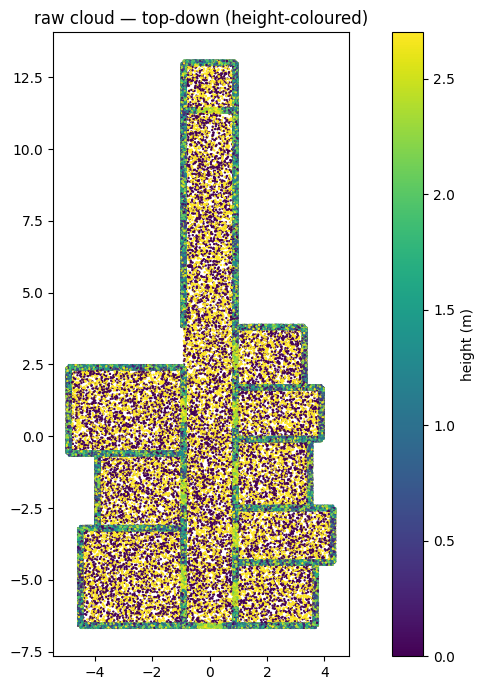

In [174]:
# DEBUG: top-down view of the raw cloud, coloured by height. Sanity-check that the
# plan looks like rooms from above (correct up_axis) and the extent is in metres.
show_topdown(points, CFG.up_axis, title="raw cloud — top-down (height-coloured)")

### 11.2 Slab crop

In [175]:
slab_pts, slab_mask, slab_info = crop_vertical(points, CFG, debug=True, return_info=True)

[crop_vertical] mode=ceiling  band(m,mean)=[2.29,2.49]  kept 19,819/273,392 (7.2%)  local ceiling range [0.00,2.70] m


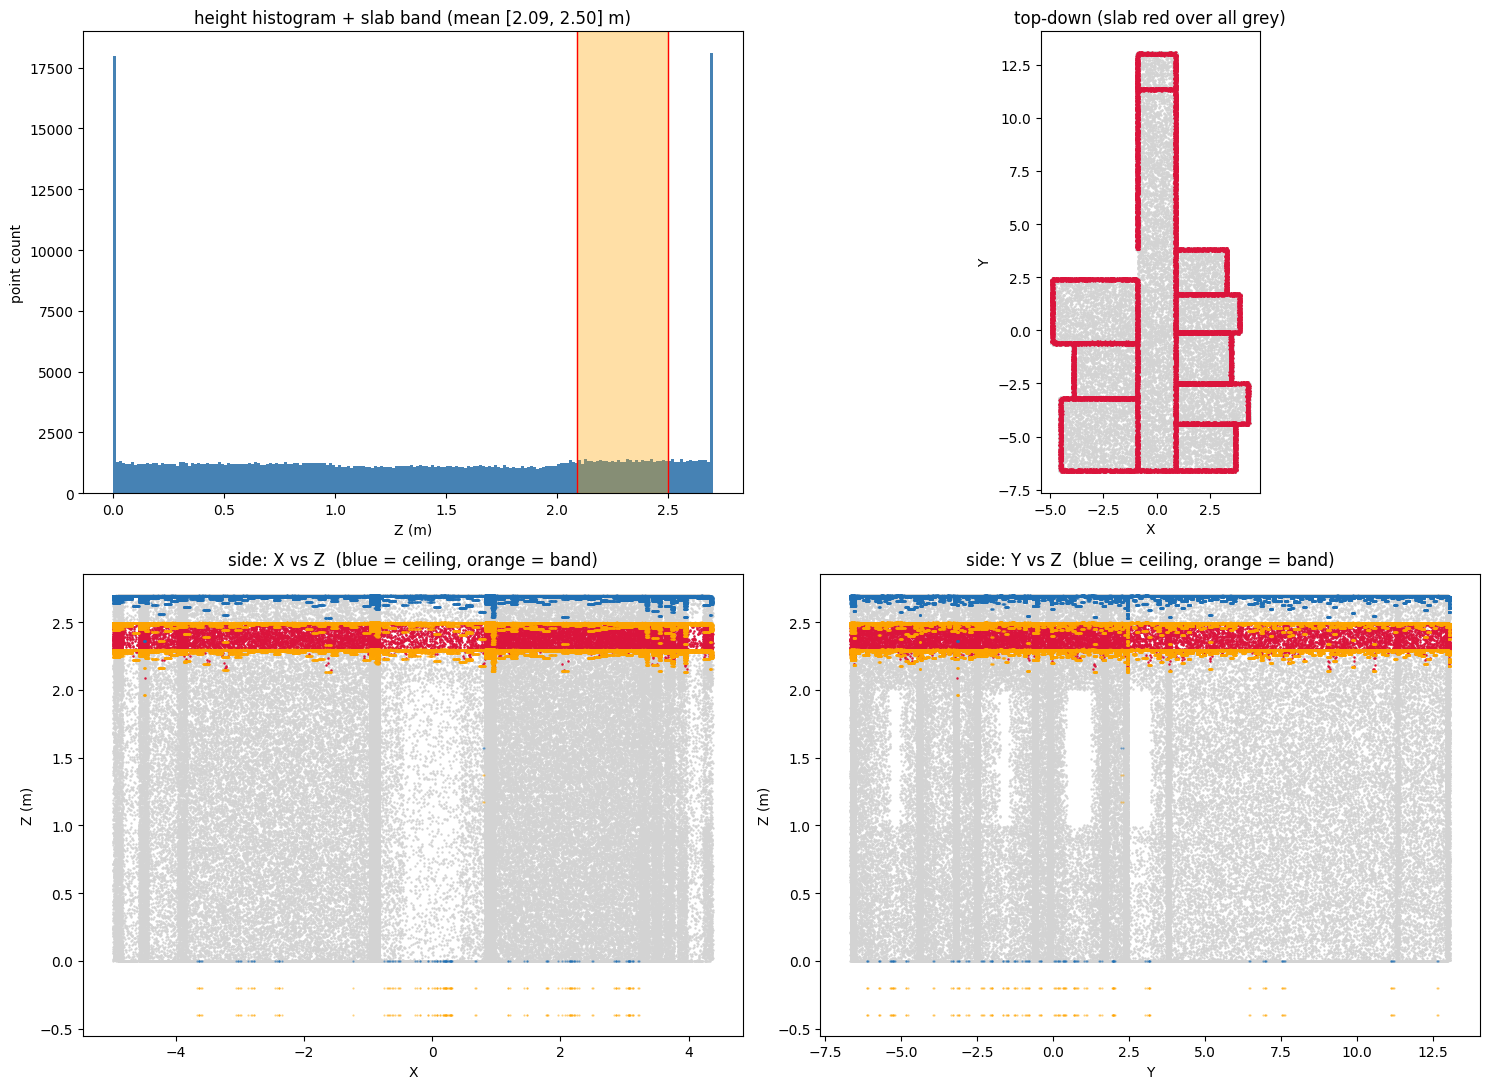

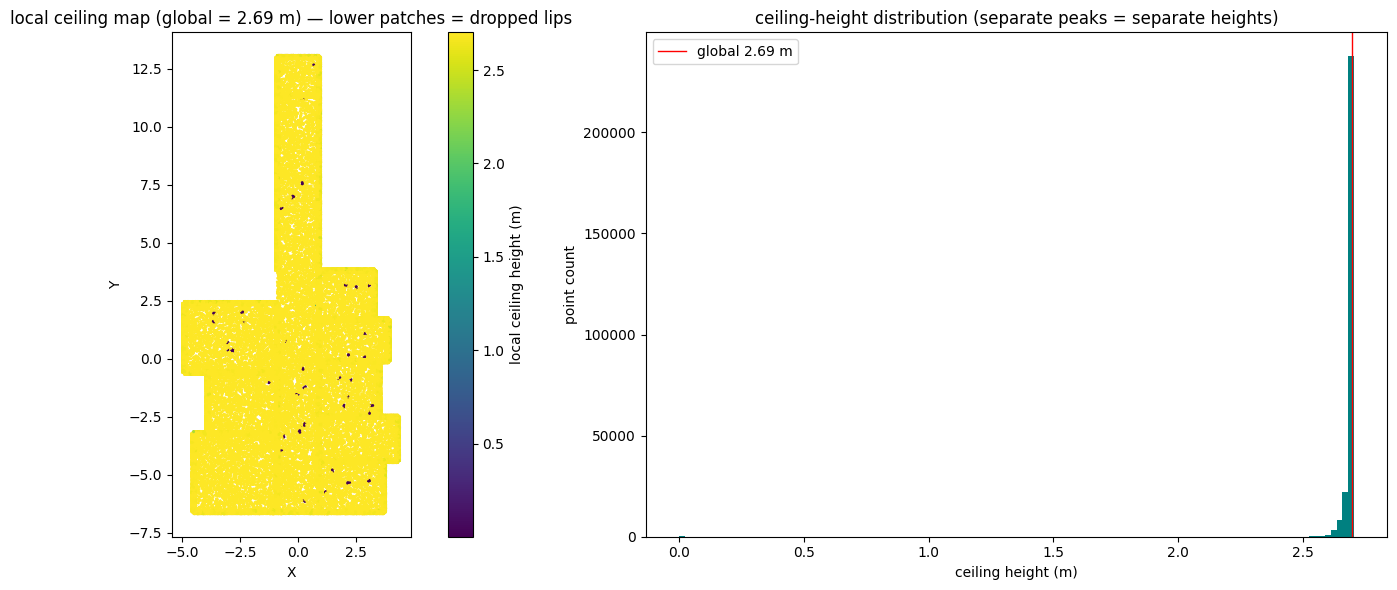

In [176]:
# DEBUG: where is the crop? Side panels show the ceiling profile (blue) and the slab band
# (orange) in elevation -- with a local ceiling you'll see both step down under a lip.
show_slab_debug(points, slab_mask, CFG.up_axis, slab_info)

# DEBUG: local ceiling height across the footprint. Lower-coloured patches = dropped lips;
# a second histogram peak = a distinct ceiling height. Confirms the lips are detected.
show_ceiling_map(points, CFG)

### 11.3 Rasterise (binary, or optional wall-likeness)

In [177]:
occ, tf = rasterize_topdown(slab_pts, CFG.pixel_m, up_axis=CFG.up_axis,
                            min_points_per_cell=CFG.min_points_per_cell,
                            thicken=CFG.thicken_px)
wall_mask = (occ == 0)

if CFG.use_wallness:
    # vertical-extent wall mask from the FULL cloud (suppresses furniture)
    wall_mask = rasterize_wallness(points, CFG, tf)

print("occupancy grid:", wall_mask.shape, "| wall px:", int(wall_mask.sum()))

# coverage map: where the scan actually has data (used to drop empty 'rooms')
coverage = rasterize_coverage(points, CFG, tf)

occupancy grid: (395, 187) | wall px: 7723


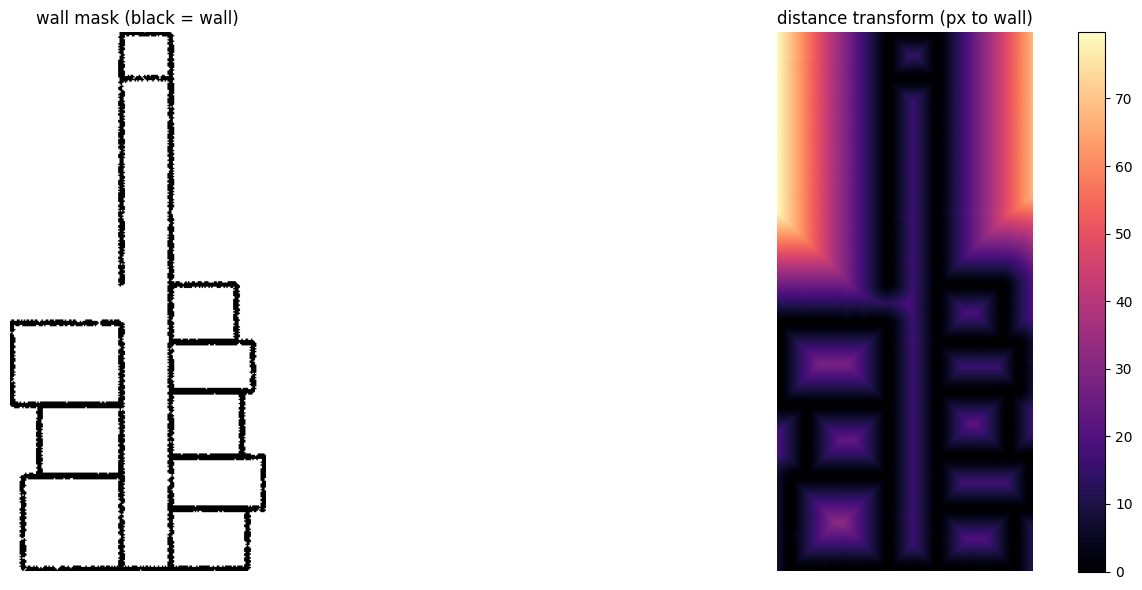

In [178]:
# DEBUG: wall mask + distance transform (the surface the watershed floods).
# Bright ridges = room cores; dark pinches = doorways. A leak shows as a bright
# channel punching through a wall line.
show_raster_debug(wall_mask)

### 11.4 Pass 1 — deterministic watershed (high precision)

In [179]:
# OPTIONAL: seal only at detected doors instead of any blanket gap.
# doors_px = [(x0,y0,x1,y1), ...]   # from your door detector / trajectory
# wall_mask = seal_at_doors(wall_mask, doors_px)

geom_labels, aux = segment_rooms_watershed(
    wall_mask, CFG.pixel_m,
    marker_h_m=CFG.marker_h_m,
    footprint_close_m=CFG.footprint_close_m,
    merge_ridge_m=CFG.merge_ridge_m,
    min_room_area_m2=CFG.min_room_area_m2,
    min_wall_area_px=CFG.min_wall_area_px,
    coverage=coverage if CFG.drop_empty_rooms else None,
    min_coverage_frac=CFG.min_coverage_frac,
    return_aux=True,
)
labels = geom_labels
print("Pass 1 rooms:", int(geom_labels.max()))
print("room_coverage:", {k: round(v, 3) for k, v in aux['room_coverage'].items()})
print("min_coverage_frac threshold:", CFG.min_coverage_frac)
print("\n--- per-final-room diagnostics ---")

for r in [int(x) for x in np.unique(labels) if x >= 1]:
    interior = (labels == r)
    rad = _min_inscribed_radius_m(interior, CFG.pixel_m)
    cov = float((interior & coverage).sum() / max(1, int(interior.sum()))) if coverage is not None else float('nan')
    print(f"  final room {r:2d}: radius={rad:.2f} m  coverage={cov:.2f}")

    print("\n--- phantom gate (preview, nothing dropped yet) ---")
for r in [int(x) for x in np.unique(labels) if x >= 1]:
    interior = (labels == r)
    rad = _min_inscribed_radius_m(interior, CFG.pixel_m)
    cov = float((interior & coverage).sum() / max(1, int(interior.sum())))
    verdict = "DROP" if _is_phantom(cov, rad) else "keep"
    print(f"  room {r:2d}: radius={rad:.2f}  cov={cov:.2f}  -> {verdict}")

Pass 1 rooms: 10
room_coverage: {1: 1.0, 2: 0.993, 3: 0.99, 4: 1.0, 5: 1.0, 6: 0.992, 7: 0.004, 8: 0.994, 9: 0.012, 10: 0.992, 11: 0.996, 12: 1.0}
min_coverage_frac threshold: 0.25

--- per-final-room diagnostics ---
  final room  1: radius=0.71 m  coverage=1.00

--- phantom gate (preview, nothing dropped yet) ---
  final room  2: radius=0.89 m  coverage=0.99

--- phantom gate (preview, nothing dropped yet) ---
  final room  3: radius=0.95 m  coverage=0.99

--- phantom gate (preview, nothing dropped yet) ---
  final room  4: radius=1.40 m  coverage=1.00

--- phantom gate (preview, nothing dropped yet) ---
  final room  5: radius=0.80 m  coverage=1.00

--- phantom gate (preview, nothing dropped yet) ---
  final room  6: radius=1.10 m  coverage=0.99

--- phantom gate (preview, nothing dropped yet) ---
  final room  7: radius=1.20 m  coverage=0.99

--- phantom gate (preview, nothing dropped yet) ---
  final room  8: radius=0.85 m  coverage=0.99

--- phantom gate (preview, nothing dropped 

In [180]:
# Find the surviving corridor seam between the upper (label 1) and lower (label 2) regions.
import numpy as np
from collections import defaultdict

walls = aux['walls']; dt = aux['dt']
lab = labels  # FINAL labels

# locate the row where corridor flips 1 -> 2
H = lab.shape[0]
flip_row = None
prev = None
for row in range(int(H*0.15), int(H*0.55)):
    rl = lab[row][lab[row] >= 1]
    if len(rl):
        dom = np.bincount(rl).argmax()
        if prev is not None and dom != prev:
            flip_row = row; print(f"corridor flips {prev} -> {dom} at row {row}")
        prev = dom
if flip_row is None:
    print("no clean flip found in scan band; widen band")

# now inspect the seam between label 1 and label 2 directly
a_mask = (lab == 1); b_mask = (lab == 2)
# dilate b by 1px, intersect with a's border -> the touching seam
from scipy import ndimage as ndi
b_dil = ndi.binary_dilation(b_mask, iterations=1)
seam = a_mask & b_dil
nseam = int(seam.sum())
wall_on_seam = int((seam & walls).sum())
print(f"label1<->label2 direct contact: {nseam} px, of which wall-adjacent: {wall_on_seam}")
if nseam:
    print(f"open_frac at this seam ~ {1 - wall_on_seam/nseam:.2f}")
# how wide is the gap if they DON'T touch?
if nseam == 0:
    d1 = ndi.distance_transform_edt(~a_mask)
    gap_px = d1[b_mask].min()
    print(f"label1 and label2 do NOT touch — nearest gap = {gap_px:.1f}px "
          f"= {gap_px*CFG.pixel_m:.2f}m (likely wall/label-0 between them)")

corridor flips 2 -> 3 at row 188
corridor flips 3 -> 4 at row 216
label1<->label2 direct contact: 0 px, of which wall-adjacent: 0
label1 and label2 do NOT touch — nearest gap = 2.0px = 0.10m (likely wall/label-0 between them)


In [181]:
# Is the top corridor ONE label in the FINAL labels the panel uses?
# Sample two points: one in corridor-top region, one lower in it.
# Easier: print the label of the largest connected component spanning the corridor.
import numpy as np
ys, xs = np.where(labels >= 1)
print("final labels present:", sorted(int(x) for x in np.unique(labels) if x >= 1))
# print centroid label of the top strip vs mid strip of the corridor
H = labels.shape[0]
for frac, name in [(0.10,"corridor TOP"), (0.25,"corridor UPPER-MID"), (0.40,"corridor LOWER-MID")]:
    row = int(H*frac)
    rowlabels = labels[row][labels[row] >= 1]
    if len(rowlabels):
        vals, counts = np.unique(rowlabels, return_counts=True)
        print(f"{name} (row {row}): dominant label = {vals[np.argmax(counts)]}  all={dict(zip(vals.tolist(),counts.tolist()))}")

final labels present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
corridor TOP (row 39): dominant label = 2  all={2: 33}
corridor UPPER-MID (row 98): dominant label = 2  all={2: 32}
corridor LOWER-MID (row 158): dominant label = 2  all={2: 32}


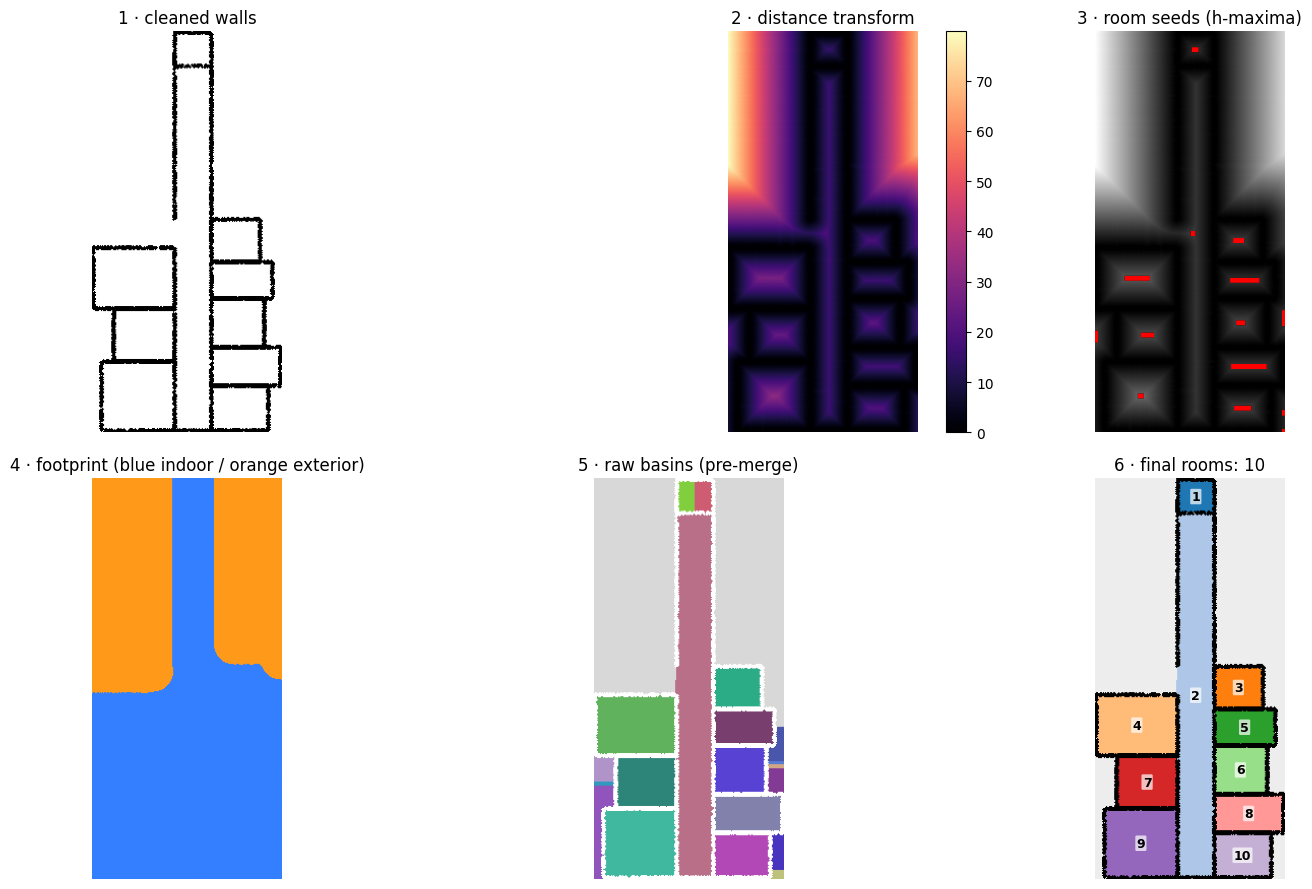

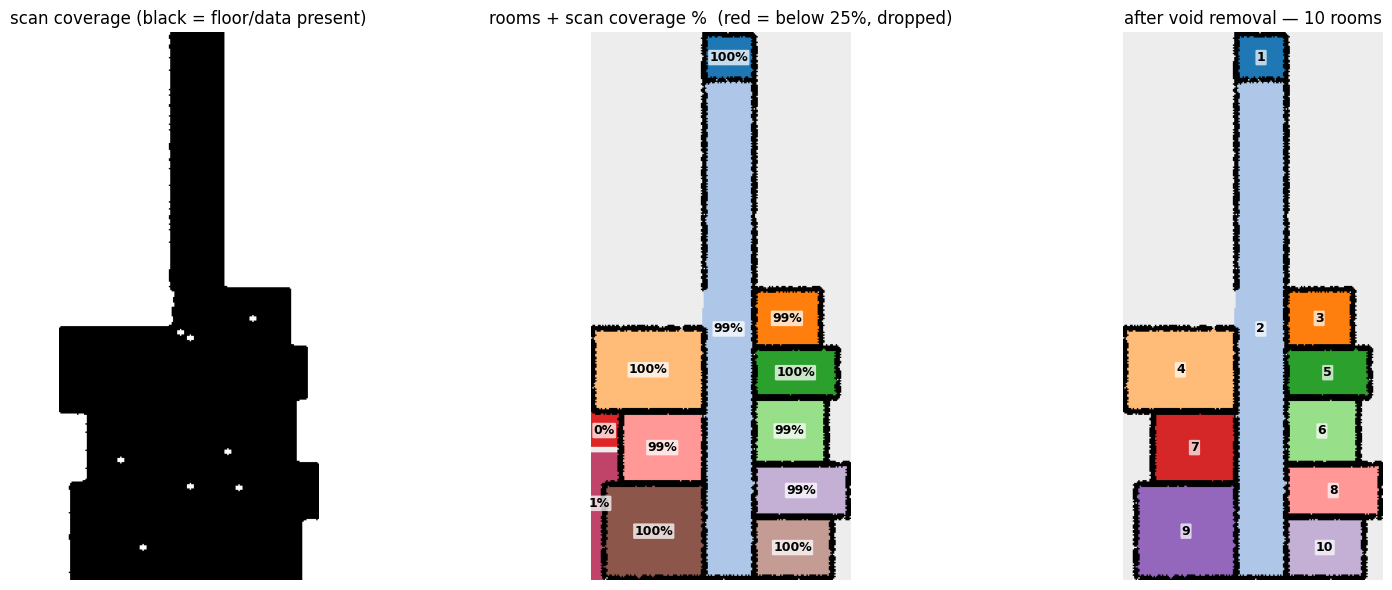

In [182]:
# DEBUG: the six internal stages of Pass 1. Read panels 3/4/5 to diagnose any
# missing room, swallowed room, or fused pair (see notes in section 10).
show_watershed_internals(aux, geom_labels, CFG.pixel_m)

# DEBUG: empty-space rejection. Panel 2 shows each room's scan-coverage %; rooms tinted
# red sit over unscanned void and are dropped (panel 3). Tune CFG.min_coverage_frac.
show_coverage_debug(aux, geom_labels, CFG)

In [183]:
print("cfg.sam_model_cfg =", repr(CFG.sam_model_cfg))
print("cfg.sam_ckpt =", repr(CFG.sam_ckpt))

cfg.sam_model_cfg = ''
cfg.sam_ckpt = '/content/sam_vit_h.pth'


In [184]:
# CORRECTED PREVIEW — scans the TRUE pre-merge labels, merges nothing.
import numpy as np
walls_dbg = aux['walls']; dt_dbg = aux['dt']; ws = aux['ws']
footprint = aux['footprint']; n_int = aux['n_int']
pixel_m = CFG.pixel_m
min_area_px = int(round(CFG.min_room_area_m2 / (pixel_m**2)))

# rebuild labels exactly as they are at the merge_wide_connections call
lab = np.zeros(ws.shape, np.int32); rid = 1
for b in range(1, n_int+1):
    m = (ws == b)
    if m.sum() == 0: continue
    inside = (m & footprint).sum() / m.sum()
    if m.sum() >= min_area_px and inside >= 0.5:
        lab[m] = rid; rid += 1
print("pre-merge room count:", rid-1)

border_tot, border_wall, contact = {}, {}, {}
def _scan(la, lb, wa, wb, da, db):
    m = (la >= 1) & (lb >= 1) & (la != lb)
    if not m.any(): return
    wsd = (wa | wb); ds = np.maximum(da, db)
    for x, y, w, d in zip(la[m], lb[m], wsd[m], ds[m]):
        key = (min(int(x),int(y)), max(int(x),int(y)))
        border_tot[key] = border_tot.get(key,0)+1
        border_wall[key] = border_wall.get(key,0)+(1 if w else 0)
        if d > contact.get(key,0.0): contact[key] = float(d)

_scan(lab[:,:-1], lab[:,1:], walls_dbg[:,:-1], walls_dbg[:,1:], dt_dbg[:,:-1], dt_dbg[:,1:])
_scan(lab[:-1,:], lab[1:,:], walls_dbg[:-1,:], walls_dbg[1:,:], dt_dbg[:-1,:], dt_dbg[1:,:])

print(f"{'pair':>10} {'border_px':>10} {'open_frac':>10} {'width_m':>8}")
for key in sorted(border_tot, key=lambda k: -border_tot[k]):
    tot = border_tot[key]; wall = border_wall[key]
    if tot >= 4:
        print(f"{str(key):>10} {tot:>10d} {1-wall/tot:>10.2f} {contact[key]*pixel_m:>8.2f}")

pre-merge room count: 13
      pair  border_px  open_frac  width_m
    (1, 2)         28       1.00     0.71


In [185]:
import inspect
src = inspect.getsource(merge_wide_connections)
print("wall_mask" in src, "open_border_frac" in src)
print(inspect.signature(merge_wide_connections))

True True
(labels, dt, merge_ridge_m, pixel_m, wall_mask=None, open_border_frac=0.8, min_border_px=8)


In [186]:
print("wall_mask=walls" in inspect.getsource(segment_rooms_watershed))

True


In [187]:
import numpy as np
h = points[:, CFG.up_axis]
print("height range:", h.min(), "to", h.max(), " span:", h.max()-h.min())
print("percentiles:", np.percentile(h, [1,5,25,50,75,95,99]))
fz, cz = estimate_ceiling(h, return_floor=True)
print("estimated floor_z:", fz, " ceiling_z:", cz, " room height:", cz-fz)

height range: 0.0 to 2.700000047683716  span: 2.700000047683716
percentiles: [0.         0.         0.57316538 1.36619198 2.17650801 2.70000005
 2.70000005]
estimated floor_z: 0.0052734375931322575  ceiling_z: 2.6947266100905836  room height: 2.6894531724974513


### 11.5 Pass 2 — SAM recall on the residual + fuse  (set `CFG.use_sam_recall=True`)

In [188]:
# labels = geom_labels
# if CFG.use_sam_recall:
#     gen = build_sam_mask_generator(CFG)
#     sam_masks = sam_auto_masks(gen, np.where(aux['walls'], 0, 255).astype(np.uint8))
#     sam_rooms = sam_rooms_on_residual(
#         sam_masks, aux['walls'], geom_labels, aux['footprint'], CFG.pixel_m,
#         min_room_area_m2=CFG.min_room_area_m2, min_overlap=CFG.sam_min_overlap)
#     labels = fuse_labels(geom_labels, sam_rooms)
#     print(f"Pass 1: {int(geom_labels.max())} rooms  ->  fused: {int(labels.max())} "
#           f"(+{int(labels.max()) - int(geom_labels.max())} from SAM)")
# else:
#     print("SAM recall disabled (CFG.use_sam_recall = False) — using Pass-1 labels.")

In [189]:
# # DEBUG: what SAM added. Middle = residual free space SAM was allowed to claim;
# # right = the fused result. With SAM off, left and right are identical (expected).
# show_sam_debug(aux, geom_labels, labels)

### 11.6 Project to 3-D and export per-room WALLS (no roof, no furniture)

A wall point = its column is a *bounding-wall* column (`walls_only=True`, buffered outward by
`do_buffer_m` ≈ half the wall thickness, the paper's `do`) **and** its height is in the band
between floor and ceiling (drops the roof slab and the floor).

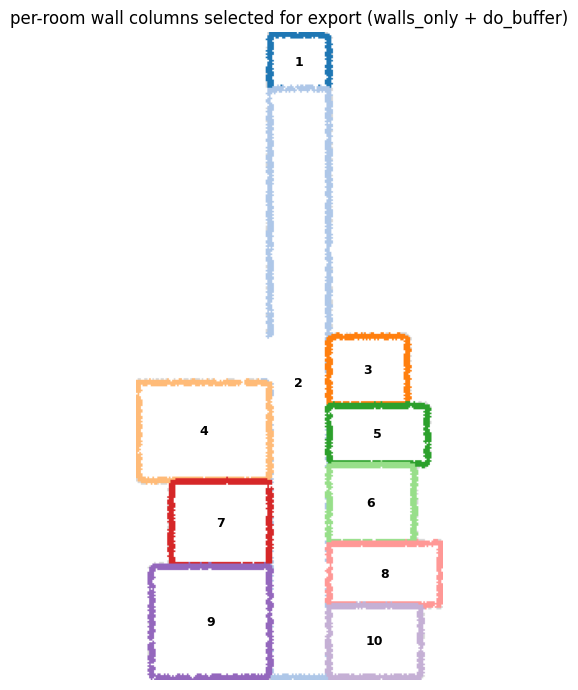

In [190]:
# DEBUG: which wall columns each room exports (walls_only + do_buffer margin).
# If neighbouring rooms grab each other's walls, lower CFG.do_buffer_m.
show_room_footprints(labels, CFG.do_buffer_px)

In [191]:
import os, zipfile
os.makedirs(CFG.out_dir, exist_ok=True)

xyz = np.asarray(pcd.points)
colors = np.asarray(pcd.colors) if pcd.has_colors() else None

zaxis = tf['up_axis']
floor_z, ceil_z = estimate_ceiling(xyz[:, zaxis], return_floor=True)
z = xyz[:, zaxis]
band = (z >= floor_z + CFG.wall_floor_margin_m) & (z <= ceil_z - CFG.wall_ceiling_margin_m)
print(f"floor ~ {floor_z:.2f} m, ceiling ~ {ceil_z:.2f} m  -> band keeps {100*band.mean():.1f}%")

rooms = split_rooms_to_clouds(
    xyz, labels, tf, colors=colors,
    margin=CFG.do_buffer_px, walls_only=True, keep_mask=band)

paths = []
for r in rooms:
    if len(r['points']) == 0:
        continue
    out = o3d.geometry.PointCloud()
    out.points = o3d.utility.Vector3dVector(r['points'])
    if 'colors' in r:
        out.colors = o3d.utility.Vector3dVector(r['colors'])
    p = os.path.join(CFG.out_dir, f"room_{r['room_id']:02d}_walls.ply")
    o3d.io.write_point_cloud(p, out); paths.append(p)
print(f"wrote {len(paths)} per-room wall clouds to {CFG.out_dir}")

floor ~ 0.01 m, ceiling ~ 2.69 m  -> band keeps 80.4%
wrote 10 per-room wall clouds to /content/scan2bim_out


In [ ]:
# SEAM DIAGNOSTIC — why didn't two corridor segments merge?
import numpy as np
from collections import defaultdict
walls_dbg = aux['walls']; dt_dbg = aux['dt']; lab = labels
bt, bw, cont = defaultdict(int), defaultdict(int), defaultdict(float)
def _scan(la, lb, wa, wb, da, db):
    m=(la>=1)&(lb>=1)&(la!=lb)
    if not m.any(): return
    ws=(wa|wb); ds=np.maximum(da,db)
    for x,y,w,d in zip(la[m],lb[m],ws[m],ds[m]):
        k=(min(int(x),int(y)),max(int(x),int(y)))
        bt[k]+=1; bw[k]+=1 if w else 0
        if d>cont[k]: cont[k]=float(d)
_scan(lab[:,:-1],lab[:,1:],walls_dbg[:,:-1],walls_dbg[:,1:],dt_dbg[:,:-1],dt_dbg[:,1:])
_scan(lab[:-1,:],lab[1:,:],walls_dbg[:-1,:],walls_dbg[1:,:],dt_dbg[:-1,:],dt_dbg[1:,:])

print(f"{'pair':>10} {'border_px':>9} {'open_frac':>9} {'width_m':>8}")
for k in sorted(bt, key=lambda z:-bt[z]):
    if bt[k]>=2:
        of = 1-bw[k]/bt[k]
        print(f"{str(k):>10} {bt[k]:>9d} {of:>9.2f} {cont[k]*CFG.pixel_m:>8.2f}")

# also show which rooms are elongated (bridge eligibility)
print("\nelongation per room (bridge needs >=2.5 on BOTH):")
from scipy import ndimage as ndi
for r in [int(x) for x in np.unique(lab) if x>=1]:
    ys,xs=np.where(lab==r)
    if len(xs)>=5:
        cov=np.cov(np.vstack([xs,ys])); ev=np.clip(np.linalg.eigvalsh(cov),1e-6,None)
        print(f"  room {r:2d}: elong={np.sqrt(ev[-1]/ev[0]):.2f}")

### 11.7 (optional) Fit clean vertical wall planes per room

Removes anything tall standing against a wall (cupboards, columns) by keeping only points on a
genuine vertical plane — tidy per-wall instances.

In [192]:
for r in rooms:
    if len(r['points']) < CFG.ransac_min_inliers:
        continue
    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(r['points'])
    planes = fit_walls_in_room(
        pc, up_axis=CFG.up_axis, normal_tol_deg=CFG.ransac_normal_tol_deg,
        dist_thresh=CFG.ransac_dist_thresh_m, min_inliers=CFG.ransac_min_inliers,
        max_planes=CFG.ransac_max_planes)
    print(f"room {r['room_id']:02d}: {len(planes)} wall planes")

room 01: 0 wall planes
room 02: 0 wall planes
room 03: 0 wall planes
room 04: 0 wall planes
room 05: 0 wall planes
room 06: 0 wall planes
room 07: 0 wall planes
room 08: 0 wall planes
room 09: 0 wall planes
room 10: 0 wall planes
